In [1]:
# ============================================================
# STAGE 1: IMPORT LIBRARIES AND CHECK GPU
# ============================================================

import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Allow TensorFlow to allocate GPU memory gradually
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )
        except RuntimeError as error:
            print(error)

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("TensorFlow version:", tf.__version__)
print("GPU devices:", gpus)

if gpus:
    print("GPU is ready.")
else:
    print("WARNING: GPU was not detected.")

2026-07-21 06:08:51.741773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 06:08:51.755126: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 06:08:51.761707: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-21 06:08:51.774618: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-21 06:08:52.455106: W tensorflow/compiler/tf2

NumPy version: 1.26.4
Pandas version: 2.2.3
TensorFlow version: 2.17.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready.


In [2]:
# ============================================================
# STAGE 2: SET FILE PATH AND READ YAHOO FINANCE CSV
# ============================================================

FILE_PATH = "portfolio_option1_EFA_VNQ_20years.csv"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        f"Cannot find '{FILE_PATH}'. "
        "Make sure the CSV file is in the same folder as the notebook."
    )

# Yahoo Finance CSV contains two header rows
raw = pd.read_csv(
    FILE_PATH,
    header=[0, 1]
)

print("File loaded successfully:", FILE_PATH)
print("Raw data shape:", raw.shape)

print("\nMain column groups:")
print(
    raw.columns
    .get_level_values(0)
    .unique()
    .tolist()
)

print("\nTicker level:")
print(
    raw.columns
    .get_level_values(1)
    .unique()
    .tolist()
)

display(raw.head())

File loaded successfully: portfolio_option1_EFA_VNQ_20years.csv
Raw data shape: (5154, 55)

Main column groups:
['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Ticker level:
['Ticker', 'AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']


Price Adj Close                                                        \
       Ticker      AAPL        EFA        IEF       MSFT      NVDA        QQQ   
0        Date       NaN        NaN        NaN        NaN       NaN        NaN   
1  2006-01-03  2.237673  33.620350  49.090813  18.632084  0.291656  35.273769   
2  2006-01-04  2.244259  33.899529  49.178551  18.722328  0.299822  35.640934   
3  2006-01-05  2.226598  33.729832  49.190231  18.736214  0.306612  35.794636   
4  2006-01-06  2.284073  34.184166  49.125893  18.680685  0.311649  36.443584   

                                    ...       Open       Volume             \
         SPY        TLT        VNQ  ...        VNQ         AAPL        EFA   
0        NaN        NaN        NaN  ...        NaN          NaN        NaN   
1  87.000908  47.859772  25.824440  ...  59.939999  807234400.0  7778500.0   
2  87.412918  47.974487  26.015696  ...  61.209999  619603600.0  5231500.0   
3  87.467857  47.917107  26.215464  ...  61.240002  449422400.0  4953800.0   
4  88.195740  47.828461  26.461979  ...  62.009998  704457600.0  5326600.0   

                                                                           \
        IEF         MSFT         NVDA          QQQ         SPY        TLT   
0       NaN          NaN          NaN          NaN         NaN        NaN   
1  299500.0   79973000.0  472812000.0  109350400.0  73256700.0  1392700.0   
2  112300.0   57975600.0  510072000.0   92769400.0  51899600.0   387600.0   
3  159700.0   48245500.0  646092000.0   77656900.0  47307500.0   453400.0   
4  179100.0  100963000.0  623388000.0  110053900.0  62885900.0  1193700.0   

            
       VNQ  
0      NaN  
1  70300.0  
2  75000.0  
3  31200.0  
4  36000.0  

[5 rows x 55 columns]

In [3]:
# ============================================================
# STAGE 3: EXTRACT DATE AND ADJUSTED CLOSE PRICES
# ============================================================

# The first column contains the dates
date_values = pd.to_datetime(
    raw.iloc[:, 0],
    errors="coerce"
)

main_columns = (
    raw.columns
    .get_level_values(0)
)

if "Adj Close" in main_columns:
    prices_wide = raw.xs(
        "Adj Close",
        axis=1,
        level=0,
        drop_level=True
    ).copy()

    price_field_used = "Adj Close"

elif "Close" in main_columns:
    print(
        "Adj Close was not found. "
        "Close prices will be used."
    )

    prices_wide = raw.xs(
        "Close",
        axis=1,
        level=0,
        drop_level=True
    ).copy()

    price_field_used = "Close"

else:
    raise ValueError(
        "The file does not contain "
        "'Adj Close' or 'Close' prices."
    )

# Insert date as the first column
prices_wide.insert(
    0,
    "Date",
    date_values
)

# Clean invalid rows and empty columns
prices_wide = (
    prices_wide
    .dropna(subset=["Date"])
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)

print("Price field used:", price_field_used)
print("Price data shape:", prices_wide.shape)

print("\nTickers:")
print(prices_wide.columns[1:].tolist())

display(prices_wide.head())

Price field used: Adj Close
Price data shape: (5153, 10)

Tickers:
['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']


,Date,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
0,2006-01-03,2.237673,33.620350,49.090813,18.632084,0.291656,35.273769,87.000908,47.859772,25.824440
1,2006-01-04,2.244259,33.899529,49.178551,18.722328,0.299822,35.640934,87.412918,47.974487,26.015696
2,2006-01-05,2.226598,33.729832,49.190231,18.736214,0.306612,35.794636,87.467857,47.917107,26.215464
3,2006-01-06,2.284073,34.184166,49.125893,18.680685,0.311649,36.443584,88.195740,47.828461,26.461979
4,2006-01-09,2.276588,34.200577,49.149277,18.645973,0.320348,36.588745,88.422348,47.859772,26.687244


In [4]:
# ============================================================
# STAGE 4: RESHAPE TO LONG FORMAT AND CREATE MONTHLY PRICES
# ============================================================

# Convert wide price table into long format:
# Date | Asset | Price
daily = prices_wide.melt(
    id_vars="Date",
    var_name="Asset",
    value_name="Price"
)

daily["Price"] = pd.to_numeric(
    daily["Price"],
    errors="coerce"
)

daily = (
    daily
    .dropna(subset=["Date", "Asset", "Price"])
    .sort_values(["Asset", "Date"])
    .reset_index(drop=True)
)

# Convert daily prices into end-of-month prices
monthly = (
    daily
    .set_index("Date")
    .groupby("Asset")["Price"]
    .resample("ME")
    .last()
    .reset_index()
)

monthly = (
    monthly
    .dropna(subset=["Price"])
    .sort_values(["Asset", "Date"])
    .reset_index(drop=True)
)

print("Daily long-format shape:", daily.shape)
print("Monthly dataset shape:", monthly.shape)

print("\nAssets:")
print(monthly["Asset"].unique().tolist())

print("\nMonthly date range:")
print(
    monthly["Date"].min(),
    "to",
    monthly["Date"].max()
)

print("\nNumber of monthly rows per asset:")
print(monthly.groupby("Asset").size())

display(monthly.head())
display(monthly.tail())

Daily long-format shape: (46377, 3)
Monthly dataset shape: (2214, 3)

Assets:
['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']

Monthly date range:
2006-01-31 00:00:00 to 2026-06-30 00:00:00

Number of monthly rows per asset:
Asset
AAPL    246
EFA     246
IEF     246
MSFT    246
NVDA    246
QQQ     246
SPY     246
TLT     246
VNQ     246
dtype: int64


,Asset,Date,Price
0,AAPL,2006-01-31,2.260425
1,AAPL,2006-02-28,2.050277
2,AAPL,2006-03-31,1.877549
3,AAPL,2006-04-30,2.107155
4,AAPL,2006-05-31,1.789241


,Asset,Date,Price
2209,VNQ,2026-02-28,93.850708
2210,VNQ,2026-03-31,87.925026
2211,VNQ,2026-04-30,95.488373
2212,VNQ,2026-05-31,94.863869
2213,VNQ,2026-06-30,98.150002


In [5]:
# ============================================================
# STAGE 5: CREATE FEATURES
# ============================================================

grouped_price = monthly.groupby("Asset")["Price"]

# Monthly returns
monthly["Return_1M"] = grouped_price.pct_change(1)
monthly["Return_3M"] = grouped_price.pct_change(3)
monthly["Return_6M"] = grouped_price.pct_change(6)

# Rolling volatility
monthly["Volatility_3M"] = (
    monthly
    .groupby("Asset")["Return_1M"]
    .transform(lambda x: x.rolling(3).std())
)

monthly["Volatility_6M"] = (
    monthly
    .groupby("Asset")["Return_1M"]
    .transform(lambda x: x.rolling(6).std())
)

# Moving averages
monthly["SMA_3M"] = (
    monthly
    .groupby("Asset")["Price"]
    .transform(lambda x: x.rolling(3).mean())
)

monthly["SMA_6M"] = (
    monthly
    .groupby("Asset")["Price"]
    .transform(lambda x: x.rolling(6).mean())
)

# Price relative to moving average
monthly["SMA_Ratio_3M"] = (
    monthly["Price"] / monthly["SMA_3M"] - 1
)

monthly["SMA_Ratio_6M"] = (
    monthly["Price"] / monthly["SMA_6M"] - 1
)

print("Return, volatility, and SMA features were created.")

display(
    monthly[
        [
            "Date",
            "Asset",
            "Price",
            "Return_1M",
            "Return_3M",
            "Return_6M",
            "Volatility_3M",
            "Volatility_6M",
            "SMA_Ratio_3M",
            "SMA_Ratio_6M"
        ]
    ].head(12)
)

Return, volatility, and SMA features were created.


,Date,Asset,Price,Return_1M,Return_3M,Return_6M,Volatility_3M,Volatility_6M,SMA_Ratio_3M,SMA_Ratio_6M
0,2006-01-31,AAPL,2.260425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006-02-28,AAPL,2.050277,-0.092969,NaN,NaN,NaN,NaN,NaN,NaN
2,2006-03-31,AAPL,1.877549,-0.084246,NaN,NaN,NaN,NaN,-0.089784,NaN
3,2006-04-30,AAPL,2.107155,0.122290,-0.067806,NaN,0.121840,NaN,0.047470,NaN
4,2006-05-31,AAPL,1.789241,-0.150873,-0.127317,NaN,0.142428,NaN,-0.070354,NaN
5,2006-06-30,AAPL,1.714401,-0.041828,-0.086894,NaN,0.137504,NaN,-0.083338,-0.128200
6,2006-07-31,AAPL,2.034412,0.186660,-0.034522,-0.099987,0.172253,0.133739,0.102054,0.054734
7,2006-08-31,AAPL,2.031118,-0.001619,0.135184,-0.009345,0.121978,0.127480,0.054226,0.054772
8,2006-09-30,AAPL,2.304430,0.134562,0.344160,0.227360,0.097218,0.128117,0.085296,0.154065
9,2006-10-31,AAPL,2.427164,0.053260,0.193054,0.151868,0.068516,0.122385,0.076712,0.183909


In [6]:
# ============================================================
# STAGE 6: CREATE 6-MONTH RSI
# ============================================================

monthly["Price_Change"] = (
    monthly
    .groupby("Asset")["Price"]
    .diff()
)

monthly["Gain"] = monthly[
    "Price_Change"
].clip(lower=0)

monthly["Loss"] = -monthly[
    "Price_Change"
].clip(upper=0)

monthly["Average_Gain_6M"] = (
    monthly
    .groupby("Asset")["Gain"]
    .transform(
        lambda x: x.rolling(6).mean()
    )
)

monthly["Average_Loss_6M"] = (
    monthly
    .groupby("Asset")["Loss"]
    .transform(
        lambda x: x.rolling(6).mean()
    )
)

relative_strength = (
    monthly["Average_Gain_6M"]
    / monthly["Average_Loss_6M"]
)

monthly["RSI_6M"] = (
    100 - 100 / (1 + relative_strength)
)

# Handle months with no average loss
monthly.loc[
    (
        monthly["Average_Loss_6M"] == 0
    )
    & (
        monthly["Average_Gain_6M"] > 0
    ),
    "RSI_6M"
] = 100

# Handle months with no gain and no loss
monthly.loc[
    (
        monthly["Average_Loss_6M"] == 0
    )
    & (
        monthly["Average_Gain_6M"] == 0
    ),
    "RSI_6M"
] = 50

print("RSI_6M was created.")

display(
    monthly[
        [
            "Date",
            "Asset",
            "Price",
            "Price_Change",
            "Average_Gain_6M",
            "Average_Loss_6M",
            "RSI_6M"
        ]
    ].head(15)
)

RSI_6M was created.


,Date,Asset,Price,Price_Change,Average_Gain_6M,Average_Loss_6M,RSI_6M
0,2006-01-31,AAPL,2.260425,NaN,NaN,NaN,NaN
1,2006-02-28,AAPL,2.050277,-0.210149,NaN,NaN,NaN
2,2006-03-31,AAPL,1.877549,-0.172727,NaN,NaN,NaN
3,2006-04-30,AAPL,2.107155,0.229605,NaN,NaN,NaN
4,2006-05-31,AAPL,1.789241,-0.317913,NaN,NaN,NaN
5,2006-06-30,AAPL,1.714401,-0.074840,NaN,NaN,NaN
6,2006-07-31,AAPL,2.034412,0.320010,0.091603,0.129272,41.472756
7,2006-08-31,AAPL,2.031118,-0.003294,0.091603,0.094796,49.143463
8,2006-09-30,AAPL,2.304430,0.273312,0.137154,0.066008,67.509814
9,2006-10-31,AAPL,2.427164,0.122734,0.119343,0.066008,64.387564


In [7]:
# ============================================================
# STAGE 7: CREATE NEXT-MONTH TARGET
# ============================================================

# Next-month realized return for each asset
monthly["Next_Return"] = (
    monthly
    .groupby("Asset")["Return_1M"]
    .shift(-1)
)

# Date corresponding to the next-month return
monthly["Next_Date"] = (
    monthly
    .groupby("Asset")["Date"]
    .shift(-1)
)

# Classification target:
# 1 = next-month return is positive
# 0 = next-month return is zero or negative
monthly["Target"] = (
    monthly["Next_Return"] > 0
).astype(int)

feature_cols = [
    "Return_1M",
    "Return_3M",
    "Return_6M",
    "Volatility_3M",
    "Volatility_6M",
    "SMA_Ratio_3M",
    "SMA_Ratio_6M",
    "RSI_6M"
]

required_cols = [
    "Date",
    "Next_Date",
    "Asset",
    "Price",
    "Next_Return",
    "Target"
] + feature_cols

df = (
    monthly
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=required_cols)
    .sort_values(["Asset", "Date"])
    .reset_index(drop=True)
)

print("Final dataset shape:", df.shape)
print("Feature count:", len(feature_cols))
print("Features:", feature_cols)

print("\nTarget counts:")
print(df["Target"].value_counts().sort_index())

print("\nTarget percentages:")
print(
    df["Target"]
    .value_counts(normalize=True)
    .sort_index()
    .round(3)
)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

display(df.head())

Final dataset shape: (2151, 21)
Feature count: 8
Features: ['Return_1M', 'Return_3M', 'Return_6M', 'Volatility_3M', 'Volatility_6M', 'SMA_Ratio_3M', 'SMA_Ratio_6M', 'RSI_6M']

Target counts:
Target
0     864
1    1287
Name: count, dtype: int64

Target percentages:
Target
0    0.402
1    0.598
Name: proportion, dtype: float64

Date range:
2006-07-31 00:00:00 to 2026-05-31 00:00:00


,Asset,Date,Price,Return_1M,Return_3M,Return_6M,Volatility_3M,Volatility_6M,SMA_3M,SMA_6M,...,SMA_Ratio_6M,Price_Change,Gain,Loss,Average_Gain_6M,Average_Loss_6M,RSI_6M,Next_Return,Next_Date,Target
0,AAPL,2006-07-31,2.034412,0.186660,-0.034522,-0.099987,0.172253,0.133739,1.846018,1.928839,...,0.054734,0.320010,0.320010,-0.000000,0.091603,0.129272,41.472756,-0.001619,2006-08-31,0
1,AAPL,2006-08-31,2.031118,-0.001619,0.135184,-0.009345,0.121978,0.127480,1.926644,1.925646,...,0.054772,-0.003294,0.000000,0.003294,0.091603,0.094796,49.143463,0.134562,2006-09-30,1
2,AAPL,2006-09-30,2.304430,0.134562,0.344160,0.227360,0.097218,0.128117,2.123320,1.996793,...,0.154065,0.273312,0.273312,-0.000000,0.137154,0.066008,67.509814,0.053260,2006-10-31,1
3,AAPL,2006-10-31,2.427164,0.053260,0.193054,0.151868,0.068516,0.122385,2.254237,2.050128,...,0.183909,0.122734,0.122734,-0.000000,0.119343,0.066008,64.387564,0.130489,2006-11-30,1
4,AAPL,2006-11-30,2.743881,0.130489,0.350921,0.533544,0.045809,0.088390,2.491825,2.209234,...,0.242005,0.316717,0.316717,-0.000000,0.172129,0.013022,92.966693,-0.074405,2006-12-31,0


In [8]:
# ============================================================
# STAGE 8: CREATE LSTM SEQUENCES
# ============================================================

def create_lstm_sequences(
    data,
    feature_columns,
    sequence_length=6
):
    """
    Create 6-month feature sequences separately for each asset.

    Each sequence uses the previous 6 months of features
    to predict the direction of the following month's return.
    """

    X_sequences = []
    y_sequences = []

    dates = []
    assets = []
    next_returns = []

    for asset, asset_data in data.groupby("Asset"):

        asset_data = (
            asset_data
            .sort_values("Date")
            .reset_index(drop=True)
        )

        feature_values = asset_data[
            feature_columns
        ].to_numpy(dtype=np.float32)

        target_values = asset_data[
            "Target"
        ].to_numpy(dtype=np.int32)

        return_values = asset_data[
            "Next_Return"
        ].to_numpy(dtype=np.float32)

        prediction_dates = asset_data[
            "Next_Date"
        ].to_numpy()

        for i in range(
            sequence_length - 1,
            len(asset_data)
        ):
            start = i - sequence_length + 1
            end = i + 1

            X_sequences.append(
                feature_values[start:end]
            )

            y_sequences.append(
                target_values[i]
            )

            dates.append(
                prediction_dates[i]
            )

            assets.append(asset)

            next_returns.append(
                return_values[i]
            )

    X_sequences = np.asarray(
        X_sequences,
        dtype=np.float32
    )

    y_sequences = np.asarray(
        y_sequences,
        dtype=np.int32
    )

    metadata = pd.DataFrame({
        "Date": pd.to_datetime(dates),
        "Asset": assets,
        "Next_Return": next_returns
    })

    return X_sequences, y_sequences, metadata


# Keep the same sequence length as the original Colab notebook
SEQUENCE_LENGTH = 6

X_all, y_all, metadata_all = create_lstm_sequences(
    data=df,
    feature_columns=feature_cols,
    sequence_length=SEQUENCE_LENGTH
)

print("Sequence length:", SEQUENCE_LENGTH)
print("X shape:", X_all.shape)
print("y shape:", y_all.shape)
print("Metadata shape:", metadata_all.shape)

print("\nSequence dimensions:")
print("Samples:", X_all.shape[0])
print("Months per sequence:", X_all.shape[1])
print("Features per month:", X_all.shape[2])

display(metadata_all.head())

Sequence length: 6
X shape: (2106, 6, 8)
y shape: (2106,)
Metadata shape: (2106, 3)

Sequence dimensions:
Samples: 2106
Months per sequence: 6
Features per month: 8


,Date,Asset,Next_Return
0,2007-01-31,AAPL,0.010491
1,2007-02-28,AAPL,-0.013065
2,2007-03-31,AAPL,0.098097
3,2007-04-30,AAPL,0.074158
4,2007-05-31,AAPL,0.214328


In [9]:
# ============================================================
# STAGE 9: BUILD LSTM MODEL AND SCALE SEQUENCES
# ============================================================

def build_lstm_model(
    sequence_length,
    number_of_features,
    lstm_units=32,
    dropout_rate=0.20,
    learning_rate=0.001
):
    """
    Build the pooled multi-asset LSTM model.
    """

    model = Sequential([
        Input(
            shape=(
                sequence_length,
                number_of_features
            )
        ),

        LSTM(
            lstm_units
        ),

        Dropout(
            dropout_rate
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def scale_sequences(
    X_train,
    X_validation,
    X_test
):
    """
    Fit StandardScaler only on training data.

    The scaler is then applied to validation and test data
    to avoid data leakage.
    """

    number_of_features = X_train.shape[2]

    scaler = StandardScaler()

    # Reshape from:
    # samples × months × features
    # into:
    # rows × features
    X_train_2d = X_train.reshape(
        -1,
        number_of_features
    )

    X_validation_2d = X_validation.reshape(
        -1,
        number_of_features
    )

    X_test_2d = X_test.reshape(
        -1,
        number_of_features
    )

    # Fit only on training data
    scaler.fit(
        X_train_2d
    )

    X_train_scaled = scaler.transform(
        X_train_2d
    ).reshape(
        X_train.shape
    )

    X_validation_scaled = scaler.transform(
        X_validation_2d
    ).reshape(
        X_validation.shape
    )

    X_test_scaled = scaler.transform(
        X_test_2d
    ).reshape(
        X_test.shape
    )

    return (
        X_train_scaled.astype(np.float32),
        X_validation_scaled.astype(np.float32),
        X_test_scaled.astype(np.float32)
    )


# Quick test: create the model
test_model = build_lstm_model(
    sequence_length=SEQUENCE_LENGTH,
    number_of_features=len(feature_cols),
    lstm_units=32,
    dropout_rate=0.20,
    learning_rate=0.001
)

test_model.summary()

del test_model
tf.keras.backend.clear_session()
gc.collect()

print("\nLSTM model and scaling functions are ready.")

2026-07-21 06:17:27.810183: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 998 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:81:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)


LSTM model and scaling functions are ready.


In [10]:
# ============================================================
# STAGE 10: POOLED WALK-FORWARD WITH MONTHLY CHECKPOINT
# ============================================================

def run_lstm_walk_forward_checkpoint(
    data,
    feature_columns,
    sequence_length=6,
    first_test_date="2011-01-31",
    threshold=0.50,
    lstm_units=32,
    dropout_rate=0.20,
    learning_rate=0.001,
    epochs=40,
    batch_size=32,
    patience=3,
    checkpoint_file="pooled_lstm_checkpoint.csv"
):
    """
    Expanding-window pooled multi-asset walk-forward validation.

    For each test month:
    - Use only observations before that month.
    - Split historical dates into 85% training and 15% validation.
    - Fit the scaler only on training data.
    - Train one pooled LSTM across all assets.
    - Predict all available assets for the test month.
    - Save a checkpoint after every completed month.
    """

    X_all, y_all, metadata = create_lstm_sequences(
        data=data,
        feature_columns=feature_columns,
        sequence_length=sequence_length
    )

    metadata = metadata.reset_index(drop=True)

    first_test_date = pd.Timestamp(first_test_date)

    test_dates = sorted(
        pd.to_datetime(
            metadata.loc[
                metadata["Date"] >= first_test_date,
                "Date"
            ].unique()
        )
    )

    if len(test_dates) == 0:
        raise ValueError(
            "No test dates were found on or after "
            f"{first_test_date.date()}."
        )

    # --------------------------------------------------------
    # Load prior checkpoint
    # --------------------------------------------------------

    if os.path.exists(checkpoint_file):
        saved_results = pd.read_csv(
            checkpoint_file,
            parse_dates=["Date"]
        )

        completed_dates = set(
            pd.to_datetime(
                saved_results["Date"]
            ).dt.normalize()
        )

        print(
            f"Loaded checkpoint with "
            f"{len(saved_results)} prediction rows."
        )

        print(
            f"Completed test months: "
            f"{len(completed_dates)}"
        )

    else:
        saved_results = pd.DataFrame()

        completed_dates = set()

        print("No checkpoint found. Starting a new run.")

    remaining_dates = [
        pd.Timestamp(date)
        for date in test_dates
        if pd.Timestamp(date).normalize()
        not in completed_dates
    ]

    print("Total test months:", len(test_dates))
    print("Remaining test months:", len(remaining_dates))

    # --------------------------------------------------------
    # Walk-forward loop
    # --------------------------------------------------------

    for step, test_date in enumerate(
        remaining_dates,
        start=1
    ):
        test_date = pd.Timestamp(test_date)

        print(
            "\n"
            f"Step {step}/{len(remaining_dates)} | "
            f"Predicting {test_date.date()}",
            flush=True
        )

        past_mask = (
            metadata["Date"] < test_date
        ).to_numpy()

        test_mask = (
            metadata["Date"] == test_date
        ).to_numpy()

        X_past = X_all[past_mask]
        y_past = y_all[past_mask]

        X_test = X_all[test_mask]
        y_test = y_all[test_mask]

        past_metadata = (
            metadata.loc[past_mask]
            .reset_index(drop=True)
        )

        test_metadata = (
            metadata.loc[test_mask]
            .reset_index(drop=True)
        )

        if len(X_past) == 0 or len(X_test) == 0:
            print("Skipped: no training or test samples.")
            continue

        unique_past_dates = sorted(
            pd.to_datetime(
                past_metadata["Date"].unique()
            )
        )

        if len(unique_past_dates) < 10:
            print("Skipped: fewer than 10 historical dates.")
            continue

        split_position = int(
            len(unique_past_dates) * 0.85
        )

        train_dates = unique_past_dates[
            :split_position
        ]

        validation_dates = unique_past_dates[
            split_position:
        ]

        train_mask_inside = (
            past_metadata["Date"]
            .isin(train_dates)
            .to_numpy()
        )

        validation_mask_inside = (
            past_metadata["Date"]
            .isin(validation_dates)
            .to_numpy()
        )

        X_train = X_past[
            train_mask_inside
        ]

        y_train = y_past[
            train_mask_inside
        ]

        X_validation = X_past[
            validation_mask_inside
        ]

        y_validation = y_past[
            validation_mask_inside
        ]

        if (
            len(X_train) == 0
            or len(X_validation) == 0
        ):
            print("Skipped: empty train or validation set.")
            continue

        (
            X_train_scaled,
            X_validation_scaled,
            X_test_scaled
        ) = scale_sequences(
            X_train,
            X_validation,
            X_test
        )

        tf.keras.backend.clear_session()
        gc.collect()

        random.seed(SEED)
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        model = build_lstm_model(
            sequence_length=sequence_length,
            number_of_features=len(
                feature_columns
            ),
            lstm_units=lstm_units,
            dropout_rate=dropout_rate,
            learning_rate=learning_rate
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=0
        )

        history = model.fit(
            X_train_scaled,
            y_train,
            validation_data=(
                X_validation_scaled,
                y_validation
            ),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stopping],
            verbose=0
        )

        probabilities = model.predict(
            X_test_scaled,
            verbose=0
        ).ravel()

        predictions = (
            probabilities >= threshold
        ).astype(int)

        month_results = test_metadata.copy()

        month_results["Actual"] = y_test
        month_results["Probability"] = probabilities
        month_results["Prediction"] = predictions
        month_results["Epochs_Used"] = len(
            history.history["loss"]
        )

        saved_results = pd.concat(
            [
                saved_results,
                month_results
            ],
            ignore_index=True
        )

        saved_results = (
            saved_results
            .drop_duplicates(
                subset=["Date", "Asset"],
                keep="last"
            )
            .sort_values(
                ["Date", "Asset"]
            )
            .reset_index(drop=True)
        )

        saved_results.to_csv(
            checkpoint_file,
            index=False
        )

        print(
            f"Saved {len(month_results)} asset predictions | "
            f"epochs used: {len(history.history['loss'])} | "
            f"total saved rows: {len(saved_results)}",
            flush=True
        )

        del model
        del history
        del X_train_scaled
        del X_validation_scaled
        del X_test_scaled

        tf.keras.backend.clear_session()
        gc.collect()

    if saved_results.empty:
        raise ValueError(
            "No predictions were generated."
        )

    print("\nWalk-forward checkpoint run is complete.")

    return saved_results


print("Pooled walk-forward checkpoint function is ready.")

Pooled walk-forward checkpoint function is ready.


In [11]:
# ============================================================
# STAGE 11: RUN POOLED WALK-FORWARD
# ============================================================

CHECKPOINT_FILE = "pooled_lstm_checkpoint.csv"

pooled_predictions = run_lstm_walk_forward_checkpoint(
    data=df,
    feature_columns=feature_cols,
    sequence_length=6,
    first_test_date="2011-01-31",
    threshold=0.50,
    lstm_units=32,
    dropout_rate=0.20,
    learning_rate=0.001,
    epochs=40,
    batch_size=32,
    patience=3,
    checkpoint_file=CHECKPOINT_FILE
)

print("\nPrediction rows:", len(pooled_predictions))
print(
    "Completed months:",
    pooled_predictions["Date"].nunique()
)

print(
    "Assets:",
    pooled_predictions["Asset"]
    .unique()
    .tolist()
)

display(pooled_predictions.head())
display(pooled_predictions.tail())

No checkpoint found. Starting a new run.
Total test months: 186
Remaining test months: 186

Step 1/186 | Predicting 2011-01-31


2026-07-21 06:19:03.973003: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


Saved 9 asset predictions | epochs used: 4 | total saved rows: 9

Step 2/186 | Predicting 2011-02-28
Saved 9 asset predictions | epochs used: 16 | total saved rows: 18

Step 3/186 | Predicting 2011-03-31
Saved 9 asset predictions | epochs used: 16 | total saved rows: 27

Step 4/186 | Predicting 2011-04-30
Saved 9 asset predictions | epochs used: 4 | total saved rows: 36

Step 5/186 | Predicting 2011-05-31
Saved 9 asset predictions | epochs used: 11 | total saved rows: 45

Step 6/186 | Predicting 2011-06-30
Saved 9 asset predictions | epochs used: 14 | total saved rows: 54

Step 7/186 | Predicting 2011-07-31
Saved 9 asset predictions | epochs used: 4 | total saved rows: 63

Step 8/186 | Predicting 2011-08-31
Saved 9 asset predictions | epochs used: 29 | total saved rows: 72

Step 9/186 | Predicting 2011-09-30
Saved 9 asset predictions | epochs used: 14 | total saved rows: 81

Step 10/186 | Predicting 2011-10-31
Saved 9 asset predictions | epochs used: 4 | total saved rows: 90

Step 11/1

,Date,Asset,Next_Return,Actual,Probability,Prediction,Epochs_Used
0,2011-01-31,AAPL,0.051959,1,0.498434,0,4
1,2011-01-31,EFA,0.020955,1,0.496240,0,4
2,2011-01-31,IEF,-0.000213,0,0.517946,1,4
3,2011-01-31,MSFT,-0.006449,0,0.495725,0,4
4,2011-01-31,NVDA,0.553247,1,0.480473,0,4


,Date,Asset,Next_Return,Actual,Probability,Prediction,Epochs_Used
1669,2026-06-30,NVDA,-0.075508,0,0.622487,1,7
1670,2026-06-30,QQQ,-0.018196,0,0.562718,1,7
1671,2026-06-30,SPY,-0.017940,0,0.567918,1,7
1672,2026-06-30,TLT,0.023717,1,0.563122,1,7
1673,2026-06-30,VNQ,0.034641,1,0.567467,1,7


In [12]:
# ============================================================
# STAGE 12: BUILD POOLED LSTM PORTFOLIO
# AND CALCULATE CLASSIFICATION METRICS
# ============================================================

# Reload from checkpoint to make sure we use the saved results
pooled_predictions = pd.read_csv(
    "pooled_lstm_checkpoint.csv",
    parse_dates=["Date"]
)

pooled_predictions = (
    pooled_predictions
    .sort_values(["Date", "Asset"])
    .reset_index(drop=True)
)

print("Prediction rows:", len(pooled_predictions))
print("Completed months:", pooled_predictions["Date"].nunique())
print(
    "Assets:",
    pooled_predictions["Asset"].unique().tolist()
)

# ------------------------------------------------------------
# 1. Classification metrics
# ------------------------------------------------------------

y_true = pooled_predictions["Actual"]
y_pred = pooled_predictions["Prediction"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print("\nClassification Results")
print("Accuracy:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
        zero_division=0
    )
)

print("Confusion Matrix")
print(cm)

# ------------------------------------------------------------
# 2. Build monthly pooled LSTM portfolio
# ------------------------------------------------------------

portfolio_records = []

for date, month_data in pooled_predictions.groupby("Date"):

    selected = month_data.loc[
        month_data["Prediction"] == 1
    ].copy()

    selected_assets = selected[
        "Asset"
    ].tolist()

    if len(selected) > 0:
        portfolio_return = selected[
            "Next_Return"
        ].mean()
    else:
        portfolio_return = 0.0

    portfolio_records.append({
        "Date": date,
        "LSTM_Return": float(portfolio_return),
        "Number_Selected": len(selected_assets),
        "Selected_Assets": ", ".join(selected_assets)
    })

pooled_lstm_portfolio = pd.DataFrame(
    portfolio_records
)

pooled_lstm_portfolio["Date"] = pd.to_datetime(
    pooled_lstm_portfolio["Date"]
)

pooled_lstm_portfolio = (
    pooled_lstm_portfolio
    .set_index("Date")
    .sort_index()
)

print("\nPooled LSTM portfolio shape:")
print(pooled_lstm_portfolio.shape)

print("\nAverage number of selected assets:")
print(
    round(
        pooled_lstm_portfolio[
            "Number_Selected"
        ].mean(),
        2
    )
)

display(pooled_lstm_portfolio.head())
display(pooled_lstm_portfolio.tail())

Prediction rows: 1674
Completed months: 186
Assets: ['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']

Classification Results
Accuracy: 0.58
F1 Score: 0.7274

Classification Report
              precision    recall  f1-score   support

           0     0.3300    0.0493    0.0858       669
           1     0.5959    0.9333    0.7274      1005

    accuracy                         0.5800      1674
   macro avg     0.4630    0.4913    0.4066      1674
weighted avg     0.4897    0.5800    0.4710      1674

Confusion Matrix
[[ 33 636]
 [ 67 938]]

Pooled LSTM portfolio shape:
(186, 3)

Average number of selected assets:
8.46


,LSTM_Return,Number_Selected,Selected_Assets
Date,,,
2011-01-31,-0.015512,2,"IEF, TLT"
2011-02-28,0.012863,9,"AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ"
2011-03-31,-0.032115,9,"AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ"
2011-04-30,0.040472,5,"EFA, IEF, MSFT, NVDA, TLT"
2011-05-31,-0.000642,9,"AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ"


,LSTM_Return,Number_Selected,Selected_Assets
Date,,,
2026-02-28,-0.000021,9,"AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ"
2026-03-31,-0.046354,9,"AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ"
2026-04-30,0.078514,9,"AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ"
2026-05-31,0.055192,9,"AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ"
2026-06-30,-0.035710,9,"AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ"


In [13]:
# ============================================================
# STAGE 13: CREATE ALL BENCHMARKS AND COMPARE PERFORMANCE
# ============================================================

from scipy.optimize import minimize


# ------------------------------------------------------------
# 1. Performance metric function
# ------------------------------------------------------------

def calculate_performance_metrics(
    return_series,
    risk_free_rate=0.0
):
    """
    Calculate performance metrics from monthly returns.
    """

    returns = pd.Series(
        return_series
    ).dropna()

    if len(returns) == 0:
        return {
            "Cumulative Return": np.nan,
            "CAGR": np.nan,
            "Annual Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Maximum Drawdown": np.nan
        }

    wealth = (
        1 + returns
    ).cumprod()

    cumulative_return = (
        wealth.iloc[-1] - 1
    )

    years = len(returns) / 12

    if years > 0 and wealth.iloc[-1] > 0:
        cagr = (
            wealth.iloc[-1] ** (1 / years)
        ) - 1
    else:
        cagr = np.nan

    annual_volatility = (
        returns.std() * np.sqrt(12)
    )

    annualized_average_return = (
        returns.mean() * 12
    )

    if annual_volatility > 0:
        sharpe_ratio = (
            annualized_average_return
            - risk_free_rate
        ) / annual_volatility
    else:
        sharpe_ratio = np.nan

    running_peak = wealth.cummax()

    drawdown = (
        wealth / running_peak
    ) - 1

    maximum_drawdown = drawdown.min()

    return {
        "Cumulative Return": cumulative_return,
        "CAGR": cagr,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown
    }


# ------------------------------------------------------------
# 2. Create wide monthly return table
# ------------------------------------------------------------

monthly_returns_wide = (
    monthly
    .pivot(
        index="Date",
        columns="Asset",
        values="Return_1M"
    )
    .sort_index()
)

available_assets = (
    monthly_returns_wide.columns
    .tolist()
)

print("Assets used in benchmarks:")
print(available_assets)


# ------------------------------------------------------------
# 3. Equal Weight, SPY, and 60/40
# ------------------------------------------------------------

equal_weight_return = (
    monthly_returns_wide[
        available_assets
    ]
    .mean(axis=1)
)

benchmark_returns = pd.DataFrame({
    "Equal Weight": equal_weight_return
})

if "SPY" in monthly_returns_wide.columns:
    benchmark_returns["SPY"] = (
        monthly_returns_wide["SPY"]
    )
else:
    print("SPY benchmark was not created.")

if (
    "SPY" in monthly_returns_wide.columns
    and "TLT" in monthly_returns_wide.columns
):
    benchmark_returns["60/40"] = (
        0.60 * monthly_returns_wide["SPY"]
        + 0.40 * monthly_returns_wide["TLT"]
    )

    print("60/40 uses SPY and TLT.")

elif (
    "SPY" in monthly_returns_wide.columns
    and "IEF" in monthly_returns_wide.columns
):
    benchmark_returns["60/40"] = (
        0.60 * monthly_returns_wide["SPY"]
        + 0.40 * monthly_returns_wide["IEF"]
    )

    print("60/40 uses SPY and IEF.")

else:
    print("60/40 benchmark was not created.")


# ------------------------------------------------------------
# 4. Walk-forward Mean-Variance Optimization
# ------------------------------------------------------------

def calculate_mvo_weights(
    historical_returns,
    risk_free_rate=0.0
):
    """
    Long-only maximum-Sharpe Mean-Variance portfolio.

    Constraints:
    - weights sum to 1
    - no short selling
    """

    historical_returns = (
        historical_returns
        .dropna(axis=0, how="any")
    )

    number_of_assets = (
        historical_returns.shape[1]
    )

    equal_weights = np.repeat(
        1 / number_of_assets,
        number_of_assets
    )

    if len(historical_returns) < 12:
        return equal_weights

    expected_annual_returns = (
        historical_returns.mean() * 12
    ).to_numpy()

    annual_covariance = (
        historical_returns.cov() * 12
    ).to_numpy()

    def negative_sharpe(weights):

        portfolio_return = np.dot(
            weights,
            expected_annual_returns
        )

        portfolio_variance = np.dot(
            weights,
            np.dot(
                annual_covariance,
                weights
            )
        )

        portfolio_volatility = np.sqrt(
            max(portfolio_variance, 0)
        )

        if portfolio_volatility <= 0:
            return 1e6

        return -(
            portfolio_return - risk_free_rate
        ) / portfolio_volatility

    bounds = [
        (0.0, 1.0)
        for _ in range(number_of_assets)
    ]

    constraints = {
        "type": "eq",
        "fun": lambda weights: (
            np.sum(weights) - 1
        )
    }

    optimization_result = minimize(
        negative_sharpe,
        equal_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 1000,
            "ftol": 1e-9
        }
    )

    if not optimization_result.success:
        return equal_weights

    return optimization_result.x


test_dates = (
    pooled_lstm_portfolio.index
    .sort_values()
)

mvo_records = []

for test_date in test_dates:

    # Only returns known before the test month
    historical_returns = (
        monthly_returns_wide.loc[
            monthly_returns_wide.index < test_date,
            available_assets
        ]
    )

    # Realized returns during the test month
    current_returns = (
        monthly_returns_wide.loc[
            test_date,
            available_assets
        ]
    )

    weights = calculate_mvo_weights(
        historical_returns=historical_returns,
        risk_free_rate=0.0
    )

    mvo_return = np.dot(
        weights,
        current_returns.to_numpy()
    )

    record = {
        "Date": test_date,
        "Mean-Variance": float(mvo_return)
    }

    for asset, weight in zip(
        available_assets,
        weights
    ):
        record[f"Weight_{asset}"] = weight

    mvo_records.append(record)


mvo_results = (
    pd.DataFrame(mvo_records)
    .set_index("Date")
    .sort_index()
)

print("Mean-Variance months:", len(mvo_results))


# ------------------------------------------------------------
# 5. Combine LSTM and all benchmarks
# ------------------------------------------------------------

comparison_returns = pd.DataFrame({
    "LSTM": pooled_lstm_portfolio[
        "LSTM_Return"
    ]
})

comparison_returns = comparison_returns.join(
    benchmark_returns,
    how="left"
)

comparison_returns = comparison_returns.join(
    mvo_results[["Mean-Variance"]],
    how="left"
)

comparison_returns = (
    comparison_returns
    .dropna()
    .sort_index()
)

print("\nComparison period:")
print(
    comparison_returns.index.min(),
    "to",
    comparison_returns.index.max()
)

print("Number of test months:", len(comparison_returns))

display(comparison_returns.head())
display(comparison_returns.tail())


# ------------------------------------------------------------
# 6. Final performance table
# ------------------------------------------------------------

performance_results = {}

for strategy in comparison_returns.columns:
    performance_results[strategy] = (
        calculate_performance_metrics(
            comparison_returns[strategy],
            risk_free_rate=0.0
        )
    )

performance_table = pd.DataFrame(
    performance_results
).T

performance_table = performance_table[
    [
        "Cumulative Return",
        "CAGR",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ]
]

print("\nFinal Performance Comparison")

display(
    performance_table.style.format({
        "Cumulative Return": "{:.2%}",
        "CAGR": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

Assets used in benchmarks:
['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']
60/40 uses SPY and TLT.
Mean-Variance months: 186

Comparison period:
2011-01-31 00:00:00 to 2026-06-30 00:00:00
Number of test months: 186


,LSTM,Equal Weight,SPY,60/40,Mean-Variance
Date,,,,,
2011-01-31,-0.015512,0.074753,0.023300,0.001656,0.011251
2011-02-28,0.012863,0.012863,0.034737,0.027443,0.002818
2011-03-31,-0.032115,-0.032115,0.000120,0.000189,-0.006965
2011-04-30,0.040472,0.035796,0.028961,0.026734,0.017102
2011-05-31,-0.000642,-0.000642,-0.011215,0.006963,0.020050


,LSTM,Equal Weight,SPY,60/40,Mean-Variance
Date,,,,,
2026-02-28,-0.000021,-0.000021,-0.008642,0.013350,0.005522
2026-03-31,-0.046354,-0.046354,-0.049380,-0.046548,-0.027370
2026-04-30,0.078514,0.078514,0.105053,0.059673,0.030069
2026-05-31,0.055192,0.055192,0.052626,0.033709,0.035355
2026-06-30,-0.035710,-0.035710,-0.017940,-0.001277,-0.030443



Final Performance Comparison


,Cumulative Return,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
LSTM,911.22%,16.10%,14.23%,1.126,-31.13%
Equal Weight,1085.49%,17.30%,13.94%,1.221,-30.23%
SPY,674.38%,14.12%,14.15%,1.009,-23.93%
60/40,325.02%,9.78%,9.94%,0.992,-26.21%
Mean-Variance,235.55%,8.12%,7.90%,1.031,-20.23%


In [14]:
# ============================================================
# CHECK TARGET CLASS BALANCE
# ============================================================

target_counts = df["Target"].value_counts().sort_index()

target_percentages = (
    df["Target"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percentages.round(2))

Target counts:
Target
0     864
1    1287
Name: count, dtype: int64

Target percentages:
Target
0    40.17
1    59.83
Name: proportion, dtype: float64


In [15]:
# ============================================================
# CHECK PREDICTED POSITIVE RATE
# ============================================================

actual_positive_rate = (
    pooled_predictions["Actual"].mean()
)

predicted_positive_rate = (
    pooled_predictions["Prediction"].mean()
)

print(
    "Actual positive rate:",
    f"{actual_positive_rate:.2%}"
)

print(
    "Predicted positive rate:",
    f"{predicted_positive_rate:.2%}"
)

Actual positive rate: 60.04%
Predicted positive rate: 94.03%


Confusion Matrix Table


,Predicted Negative Return,Predicted Positive Return
Actual Negative Return,33,636
Actual Positive Return,67,938


,Metric,Value
0,Accuracy,58.00%
1,Precision,59.59%
2,Recall,93.33%
3,F1 Score,72.74%
4,Actual Positive Rate,60.04%
5,Predicted Positive Rate,94.03%


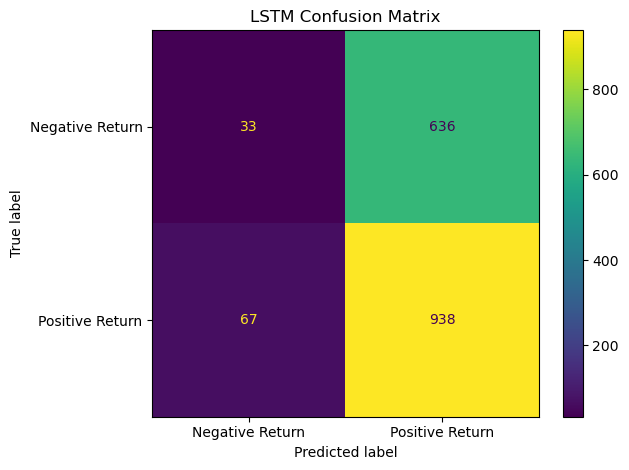


Classification Report
                 precision    recall  f1-score   support

Negative Return     0.3300    0.0493    0.0858       669
Positive Return     0.5959    0.9333    0.7274      1005

       accuracy                         0.5800      1674
      macro avg     0.4630    0.4913    0.4066      1674
   weighted avg     0.4897    0.5800    0.4710      1674



In [16]:
# ============================================================
# CONFUSION MATRIX AND CLASSIFICATION METRICS
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

y_true = pooled_predictions["Actual"]
y_pred = pooled_predictions["Prediction"]

# Confusion matrix values
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

confusion_matrix_table = pd.DataFrame(
    cm,
    index=[
        "Actual Negative Return",
        "Actual Positive Return"
    ],
    columns=[
        "Predicted Negative Return",
        "Predicted Positive Return"
    ]
)

print("Confusion Matrix Table")
display(confusion_matrix_table)

# Metrics
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

actual_positive_rate = y_true.mean()
predicted_positive_rate = y_pred.mean()

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Actual Positive Rate",
        "Predicted Positive Rate"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        actual_positive_rate,
        predicted_positive_rate
    ]
})

display(
    metrics_table.style.format({
        "Value": "{:.2%}"
    })
)

# Plot confusion matrix
display_object = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative Return",
        "Positive Return"
    ]
)

display_object.plot(
    values_format="d"
)

plt.title("LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Negative Return",
            "Positive Return"
        ],
        digits=4,
        zero_division=0
    )
)

In [17]:
# ============================================================
# THRESHOLD SENSITIVITY ANALYSIS
# Classification + Portfolio Performance
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Thresholds to test
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:

    temp = pooled_predictions.copy()

    # Create predictions using the current threshold
    temp["Prediction"] = (
        temp["Probability"] >= threshold
    ).astype(int)

    y_true = temp["Actual"].astype(int)
    y_pred = temp["Prediction"].astype(int)

    # --------------------------------------------------------
    # CLASSIFICATION METRICS
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(y_true, y_pred)

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    positive_precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    positive_recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    negative_recall = recall_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )

    positive_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    predicted_positive_rate = y_pred.mean()

    # --------------------------------------------------------
    # CREATE PORTFOLIO FOR THIS THRESHOLD
    # --------------------------------------------------------

    portfolio_rows = []

    for date, month_data in temp.groupby("Date"):

        selected = month_data[
            month_data["Prediction"] == 1
        ]

        if len(selected) > 0:

            portfolio_return = selected[
                "Next_Return"
            ].mean()

            selected_count = len(selected)

        else:

            # No assets selected: portfolio stays in cash
            portfolio_return = 0.0
            selected_count = 0

        portfolio_rows.append({
            "Date": date,
            "Portfolio_Return": portfolio_return,
            "Selected_Assets_Count": selected_count
        })

    threshold_portfolio = pd.DataFrame(
        portfolio_rows
    ).sort_values("Date")

    portfolio_returns = (
        threshold_portfolio["Portfolio_Return"]
        .dropna()
    )

    # --------------------------------------------------------
    # PORTFOLIO METRICS
    # --------------------------------------------------------

    if len(portfolio_returns) > 0:

        total_return = (
            1 + portfolio_returns
        ).prod() - 1

        years = len(portfolio_returns) / 12

        cagr = (
            (1 + total_return) ** (1 / years) - 1
            if years > 0
            else np.nan
        )

        annual_volatility = (
            portfolio_returns.std() * np.sqrt(12)
        )

        annual_return = (
            portfolio_returns.mean() * 12
        )

        sharpe_ratio = (
            annual_return / annual_volatility
            if annual_volatility > 0
            else np.nan
        )

        cumulative_growth = (
            1 + portfolio_returns
        ).cumprod()

        rolling_peak = cumulative_growth.cummax()

        drawdown = (
            cumulative_growth / rolling_peak
        ) - 1

        maximum_drawdown = drawdown.min()

    else:

        total_return = np.nan
        cagr = np.nan
        annual_volatility = np.nan
        sharpe_ratio = np.nan
        maximum_drawdown = np.nan

    average_assets_selected = (
        threshold_portfolio[
            "Selected_Assets_Count"
        ].mean()
    )

    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    threshold_results.append({
        "Threshold": threshold,

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Positive Precision": positive_precision,
        "Positive Recall": positive_recall,
        "Negative Recall": negative_recall,
        "Positive F1": positive_f1,
        "Predicted Positive Rate":
            predicted_positive_rate,

        "Average Assets Selected":
            average_assets_selected,

        "CAGR": cagr,
        "Annual Volatility":
            annual_volatility,
        "Sharpe Ratio":
            sharpe_ratio,
        "Maximum Drawdown":
            maximum_drawdown
    })


threshold_comparison = pd.DataFrame(
    threshold_results
)

# ============================================================
# DISPLAY FULL COMPARISON TABLE
# ============================================================

display(
    threshold_comparison.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Precision": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Positive F1": "{:.2%}",
        "Predicted Positive Rate": "{:.2%}",
        "Average Assets Selected": "{:.2f}",
        "CAGR": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

,Threshold,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Positive Precision,Positive Recall,Negative Recall,Positive F1,Predicted Positive Rate,Average Assets Selected,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,0.50,33,636,67,938,58.00%,49.13%,59.59%,93.33%,4.93%,72.74%,94.03%,8.46,16.10%,14.23%,1.126,-31.13%
1,0.55,237,432,402,603,50.18%,47.71%,58.26%,60.00%,35.43%,59.12%,61.83%,5.56,19.08%,17.92%,1.069,-31.13%
2,0.60,574,95,886,119,41.40%,48.82%,55.61%,11.84%,85.80%,19.52%,12.78%,1.15,21.94%,26.03%,0.890,-44.45%
3,0.65,656,13,990,15,40.08%,49.77%,53.57%,1.49%,98.06%,2.90%,1.67%,0.15,1.08%,11.23%,0.150,-35.06%
4,0.70,668,1,1005,0,39.90%,49.93%,0.00%,0.00%,99.85%,0.00%,0.06%,0.01,-1.31%,4.71%,-0.254,-18.53%


In [18]:
# ============================================================
# DISPLAY KEY THRESHOLD RESULTS
# ============================================================

key_threshold_results = threshold_comparison[[
    "Threshold",
    "Balanced Accuracy",
    "Positive Recall",
    "Negative Recall",
    "Predicted Positive Rate",
    "Average Assets Selected",
    "CAGR",
    "Sharpe Ratio",
    "Maximum Drawdown"
]]

display(
    key_threshold_results.style.format({
        "Threshold": "{:.2f}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Predicted Positive Rate": "{:.2%}",
        "Average Assets Selected": "{:.2f}",
        "CAGR": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

,Threshold,Balanced Accuracy,Positive Recall,Negative Recall,Predicted Positive Rate,Average Assets Selected,CAGR,Sharpe Ratio,Maximum Drawdown
0,0.50,49.13%,93.33%,4.93%,94.03%,8.46,16.10%,1.126,-31.13%
1,0.55,47.71%,60.00%,35.43%,61.83%,5.56,19.08%,1.069,-31.13%
2,0.60,48.82%,11.84%,85.80%,12.78%,1.15,21.94%,0.890,-44.45%
3,0.65,49.77%,1.49%,98.06%,1.67%,0.15,1.08%,0.150,-35.06%
4,0.70,49.93%,0.00%,99.85%,0.06%,0.01,-1.31%,-0.254,-18.53%


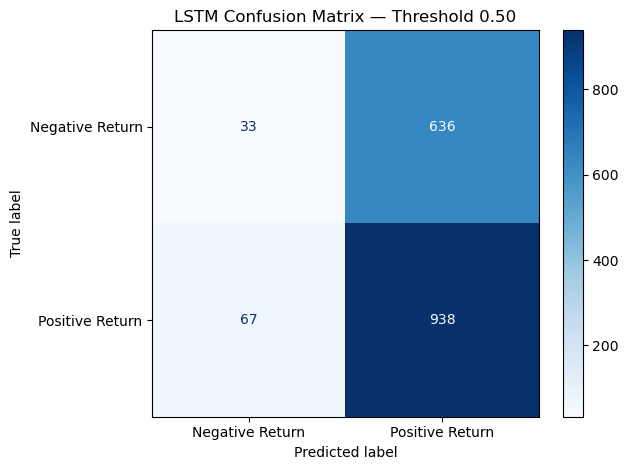

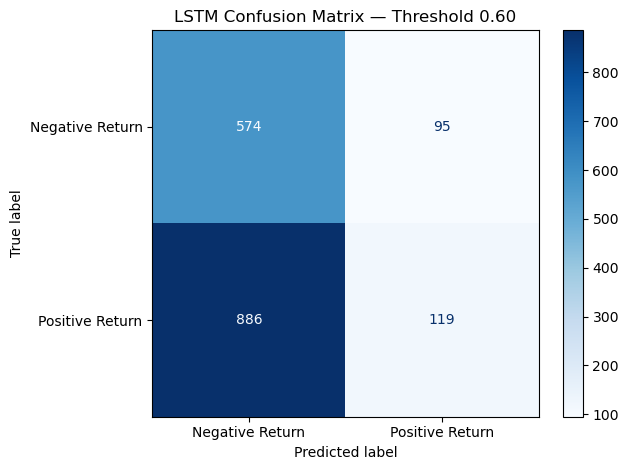

,Threshold,True Negative,False Positive,False Negative,True Positive,Accuracy,Balanced Accuracy,Positive Precision,Positive Recall,Negative Recall,Positive F1,Predicted Positive Rate
0,0.50,33,636,67,938,58.00%,49.13%,59.59%,93.33%,4.93%,72.74%,94.03%
1,0.60,574,95,886,119,41.40%,48.82%,55.61%,11.84%,85.80%,19.52%,12.78%


In [19]:
# ============================================================
# COMPARE CONFUSION MATRICES
# Thresholds: 0.50 and 0.60
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds_to_compare = [0.50, 0.60]

comparison_rows = []

for threshold in thresholds_to_compare:

    temp_results = pooled_predictions.copy()

    temp_results["Prediction"] = (
        temp_results["Probability"] >= threshold
    ).astype(int)

    y_true = temp_results["Actual"].astype(int)
    y_pred = temp_results["Prediction"].astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    negative_recall = recall_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )

    positive_recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    comparison_rows.append({
        "Threshold": threshold,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy":
            balanced_accuracy_score(y_true, y_pred),
        "Positive Precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),
        "Positive Recall": positive_recall,
        "Negative Recall": negative_recall,
        "Positive F1":
            f1_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),
        "Predicted Positive Rate": y_pred.mean()
    })

    # Plot one confusion matrix at a time
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Negative Return",
            "Positive Return"
        ]
    )

    disp.plot(
        values_format="d",
        cmap="Blues"
    )

    plt.title(
        f"LSTM Confusion Matrix — Threshold {threshold:.2f}"
    )

    plt.tight_layout()
    plt.show()


confusion_threshold_comparison = pd.DataFrame(
    comparison_rows
)

display(
    confusion_threshold_comparison.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Precision": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Positive F1": "{:.2%}",
        "Predicted Positive Rate": "{:.2%}"
    })
)